In [1]:
import importlib

import pandas as pd
import matplotlib.pyplot as plt

import src.data
import src.formal_pipeline

importlib.reload(src.data)
importlib.reload(src.formal_pipeline)

from src.formal_pipeline import FormalHackathonPipeline

In [ ]:
df = pd.read_parquet("insample_data/is_features_1_min_hackaton/l2_bid_n2_vwap_.parquet")
df

,ABIO,ABRD,AFKS,AFLT,AKMB,AKMM,AKRN,ALRS,AMNY,AMRE,...,ZAYM,ZVEZ,AKIE,DATA,HEAD,AKFB,AKHT,LMBZ,OZPH,PSRB
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-09-02 10:01:00,260.0,1800,34300.0,43650.0,35194.0,5634049.0,11,15020.0,300006,34628,...,1610.0,21000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-02 10:02:00,2280.0,1590,49100.0,53860.0,3183343.0,5899022.0,13,350230.0,300006,34628,...,1990.0,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-02 10:03:00,580.0,1500,13200.0,83860.0,95272.0,5888060.0,13,23230.0,300006,34628,...,630.0,19000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-02 10:04:00,290.0,1610,9100.0,39410.0,24952.0,5882089.0,9,14430.0,300006,34434,...,2530.0,23000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-02 10:05:00,900.0,2220,67400.0,19460.0,45022.0,5881824.0,12,28640.0,300006,34434,...,1840.0,23000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-15 23:55:00,NaN,2370,NaN,NaN,NaN,NaN,44,NaN,1213,210,...,NaN,26000.0,NaN,979.0,1444.0,NaN,NaN,NaN,NaN,NaN
2024-10-15 23:56:00,NaN,2370,NaN,NaN,NaN,NaN,44,NaN,1213,210,...,NaN,26000.0,NaN,979.0,1444.0,NaN,NaN,NaN,NaN,NaN
2024-10-15 23:57:00,NaN,2370,NaN,NaN,NaN,NaN,44,NaN,1213,210,...,NaN,26000.0,NaN,979.0,1444.0,NaN,NaN,NaN,NaN,NaN


In [2]:
pipeline = FormalHackathonPipeline(
    data_root="insample_data",
    delta=0.10,
    impact_a=0.03,
    aum_rub=50_000_000,
    x_max=0.30,
    top_n=8,
)

result = pipeline.run(max_execution_bars=1000)

result.metrics

signal_rows         2.611200e+04
execution_rows      6.856000e+03
pnl_mid_total       2.502964e-01
pnl_net_total      -5.229013e+07
sharpe_net         -1.012747e+02
hit_rate_mid        5.309436e-01
avg_is_reduction    6.213059e-01
dtype: float64

## Формальный pipeline по уточнённому ТЗ

Решение разбито на независимые таблицы модулей: `signal_5min`, `backtest_baseline`, `impact_model`, `execution_schedule`, `execution_summary`. Сигнал строится на 5-мин барах, исполнение моделируется 1-мин слайсами внутри 5-мин бара.

In [3]:
print("signal_5min", result.signal_5min.shape)
print("backtest_baseline", result.backtest_baseline.shape)
print("impact_model", result.impact_model.shape)
print("execution_schedule", result.execution_schedule.shape)
print("execution_summary", result.execution_summary.shape)

signal_5min (26112, 3)
backtest_baseline (26112, 5)
impact_model (103581, 4)
execution_schedule (29746, 6)
execution_summary (6856, 10)


## M2: `signal_5min`

Выход модуля сигнала соответствует ТЗ: конец 5-мин бара, тикер и значение сигнала в диапазоне `[-1, 1]`.

In [4]:
result.signal_5min.head()

,bar_end_ts,seccode,value
0,1725271500000000,FEES,-0.808478
1,1725271500000000,SGZH,0.245669
2,1725271500000000,AKMM,0.964317
3,1725271500000000,UNAC,0.724145
4,1725271500000000,HYDR,0.794565


In [5]:
result.backtest_baseline.head()

,bar_end_ts,seccode,pos,pnl_mid,cum_pnl_mid
0,1725271500000000,FEES,0.0,0.0,0.0
1,1725271500000000,SGZH,0.0,-0.0,-0.0
2,1725271500000000,AKMM,0.0,0.0,0.0
3,1725271500000000,UNAC,0.0,-0.0,-0.0
4,1725271500000000,HYDR,0.0,-0.0,-0.0


## M3-M5: baseline, impact и оптимизация исполнения

`backtest_baseline` считает `pnl_mid` по 5-мин барам без стоимости исполнения. `impact_model` задаёт линейный коэффициент `a(t)` на 1-мин барах. `execution_schedule` распределяет объём по 1-мин слайсам с ограничением participation rate, а `execution_summary` агрегирует IS и `pnl_net`.

In [6]:
result.impact_model.head()

,bar_end_ts,seccode,volume_mkt,a
0,1725271260000000,FEES,24620000,0.024643
1,1725271260000000,SGZH,12200700,0.035357
2,1725271260000000,AKMM,427760,0.037500
3,1725271260000000,UNAC,1087000,0.031071
4,1725271260000000,HYDR,4934000,0.028929


In [7]:
result.execution_schedule.head(10)

,bar_end_ts_5min,bar_end_ts_1min,seccode,q_slice,participation_rate,impact_cost_rel
0,1725271800000000000,1725271560000000,FEES,-1.650900e+07,0.300000,0.008036
1,1725271800000000000,1725271620000000,FEES,-5.391000e+06,0.300000,0.007312
2,1725271800000000000,1725271680000000,FEES,-5.439000e+06,0.300000,0.007875
3,1725271800000000000,1725271740000000,FEES,-1.922100e+07,0.300000,0.007312
4,1725271800000000000,1725271800000000,FEES,-5.316000e+06,0.300000,0.008036
5,1725271800000000000,1725271560000000,SGZH,4.354046e+05,0.115861,0.004097
6,1725271800000000000,1725271620000000,SGZH,3.866065e+05,0.114990,0.004097
7,1725271800000000000,1725271680000000,SGZH,2.010938e+05,0.114990,0.004097
8,1725271800000000000,1725271740000000,SGZH,3.693166e+05,0.121378,0.004097
9,1725271800000000000,1725271800000000,SGZH,6.760642e+05,0.123336,0.004097


In [8]:
result.execution_summary.head()

,bar_end_ts_5min,seccode,Q_executed,vwap_fill,twap_bench,implementation_shortfall,implementation_shortfall_twap,is_reduction,pnl_mid,pnl_net
0,1725271800000000000,FEES,5.187600e+07,0.088099,0.087794,35350.867381,49503.909869,0.285897,-41508.745359,-76859.612739
1,1725271800000000000,SGZH,2.068486e+06,1.123408,1.124629,9480.427446,11023.817102,0.140005,-2081.460022,-11561.887469
2,1725271800000000000,AKMM,1.505100e+04,127.127541,127.165520,21286.241707,21861.879655,0.026331,725.324932,-20560.916776
3,1725271800000000000,UNAC,1.500600e+06,0.611477,0.617665,8898.149344,17579.445608,0.493832,-56262.310759,-65160.460103
4,1725271800000000000,HYDR,1.276800e+06,0.519898,0.523715,5643.922236,10284.094171,0.451199,1459.114412,-4184.807823


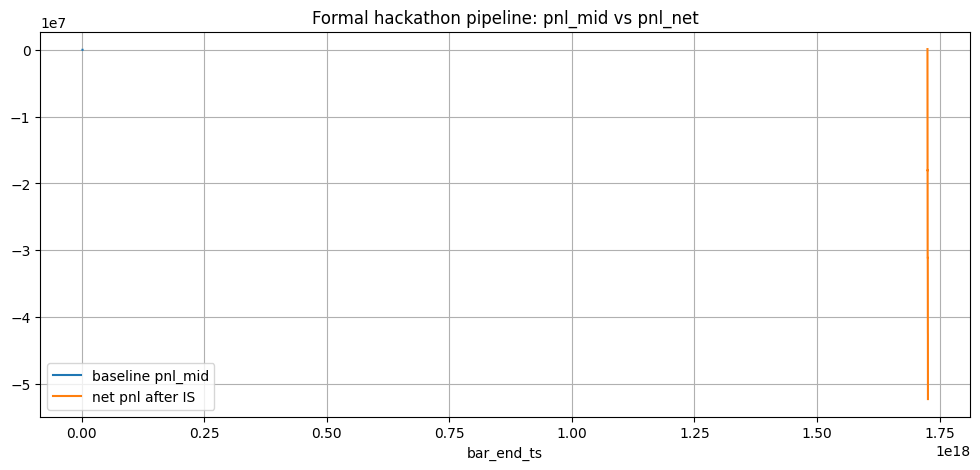

In [9]:
equity_mid = result.backtest_baseline.groupby("bar_end_ts")["pnl_mid"].sum().cumsum()
equity_net = result.execution_summary.groupby("bar_end_ts_5min")["pnl_net"].sum().cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
equity_mid.plot(ax=ax, label="baseline pnl_mid")
equity_net.plot(ax=ax, label="net pnl after IS")
ax.set_title("Formal hackathon pipeline: pnl_mid vs pnl_net")
ax.set_xlabel("bar_end_ts")
ax.grid(True)
ax.legend()
plt.show()

In [10]:
is_cols = [
    "implementation_shortfall",
    "implementation_shortfall_twap",
    "is_reduction",
    "pnl_mid",
    "pnl_net",
]

result.execution_summary[is_cols].describe()

,implementation_shortfall,implementation_shortfall_twap,is_reduction,pnl_mid,pnl_net
count,6856.000000,6.856000e+03,6856.000000,6856.000000,6856.000000
mean,8179.722618,2.471844e+06,0.621306,552.807381,-7626.915238
std,15531.479185,2.922125e+07,0.323475,25862.766813,29754.264920
min,0.017575,1.757541e-02,-0.042098,-323863.380089,-329332.917409
25%,111.586215,5.455408e+02,0.362127,-3877.556571,-13572.066606
50%,1508.977583,6.753176e+03,0.697508,-0.000000,-1813.858227
75%,8104.814664,4.220134e+04,0.920817,4668.445123,1753.260629
max,109560.924506,9.496311e+08,0.999985,300168.248925,290396.385808
